*Trabajo Práctico Nro1 - Primer Encuentro con la EPH*

- Grupo 5 del curso "M73 13 Seminarios Optativos - Taller de Programación"
- Integrantes: Santiago Caballero Yver, Oriana Valentina Gegena y Valeria Eliana Gonzalez.


In [32]:
!pip install openpyxl pandas
# Cargamos librerias a utilizar
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker


# Cargamos bases de datos T424 y T425:
T424 = pd.read_excel('C:/Users/gegen/OneDrive/Documentos/2. Economía Aplicada/Programación/usu_individual_T424.xlsx')
T425 = pd.read_excel('C:/Users/gegen/OneDrive/Documentos/2. Economía Aplicada/Programación/usu_individual_T425.xlsx')

In [8]:
# Variables de interés a utilizar en el analisis
variables = [
    "CODUSU", "ANO4", "TRIMESTRE", "NRO_HOGAR", "PONDERA", 
    "CH04", "CH06", "CH07", "CH08", "NIVEL_ED", 
    "ESTADO", "CAT_OCUP", "EMPLEO", "SECTOR", 
    "PP04C", "PP04D_COD", "P21", "P47T", 
    "PP07H", "PP3E_TOT"
]

T424_v = T424[variables].copy()
T425_v = T425[variables].copy()
    
# Variables incluidas:
# "PP07H"     Descuento jubilatorio (formalidad asalariada)
# "PP3E_TOT"  Horas trabajadas (salario horario)

#Seguimiento de variables:
#CH04 - Varón/Mujer
#CH06 - edad
#CH07 - Estado civil
#CH08 - Cobertura salud
#PP04C - Cantidad de personas que trabajan en el establecimiento
#PP04D_COD - Codigo de ocupación
#P21 - ingreso de la ocupación principal
#P47T - Ingreso total individual



In [9]:
# Resumen descriptivo de las bases para observar posibles outliers
resumen_2024 = T424_v.describe().T
resumen_2025 = T425_v.describe().T

# Mostramos el resultado del 2024
print("Resumen estadístico EPH - Cuarto Trimestre 2024:")
display(resumen_2024) 

# Mostramos el resultado del 2025
print("\nResumen estadístico EPH - Cuarto Trimestre 2025:")
display(resumen_2025)

Resumen estadístico EPH - Cuarto Trimestre 2024:


,count,mean,std,min,25%,50%,75%,max
ANO4,46860.0,2024.000000,0.000000,2024.0,2024.0,2024.0,2024.0,2024.0
TRIMESTRE,46860.0,4.000000,0.000000,4.0,4.0,4.0,4.0,4.0
NRO_HOGAR,46860.0,1.034550,0.634871,1.0,1.0,1.0,1.0,72.0
PONDERA,46860.0,635.586278,824.688160,23.0,180.0,315.0,663.0,7989.0
CH04,46860.0,1.519718,0.499616,1.0,1.0,2.0,2.0,2.0
CH06,46860.0,36.759112,22.182034,-1.0,18.0,35.0,54.0,103.0
CH07,46860.0,3.521618,1.651600,1.0,2.0,5.0,5.0,9.0
CH08,46860.0,2.134998,1.869091,1.0,1.0,1.0,4.0,123.0
NIVEL_ED,46860.0,3.780644,1.756795,1.0,3.0,4.0,5.0,7.0
ESTADO,46860.0,2.181946,1.133963,0.0,1.0,3.0,3.0,4.0



Resumen estadístico EPH - Cuarto Trimestre 2025:


,count,mean,std,min,25%,50%,75%,max
ANO4,43703.0,2025.000000,0.000000,2025.0,2025.0,2025.0,2025.0,2025.0
TRIMESTRE,43703.0,4.000000,0.000000,4.0,4.0,4.0,4.0,4.0
NRO_HOGAR,43703.0,1.039311,0.840685,1.0,1.0,1.0,1.0,71.0
PONDERA,43703.0,687.200993,905.356807,24.0,192.0,342.0,724.0,7954.0
CH04,43703.0,1.525639,0.499348,1.0,1.0,2.0,2.0,2.0
CH06,43703.0,37.586573,22.326015,-1.0,19.0,36.0,55.0,101.0
CH07,43703.0,3.513946,1.649546,1.0,2.0,5.0,5.0,9.0
CH08,43703.0,2.159714,1.768585,1.0,1.0,1.0,4.0,23.0
NIVEL_ED,43703.0,3.751504,1.737705,1.0,3.0,4.0,5.0,7.0
ESTADO,43703.0,2.168021,1.121546,0.0,1.0,3.0,3.0,4.0


In [64]:
#Comparamos variables, checks de cada tipo

tipo_var = pd.DataFrame({"var_2024": T424_v.dtypes, "var_2025": T425_v.dtypes})

# Marcamos las variables donde el tipo es distinto entre años
tipo_var["Coincidencia"] = tipo_var["var_2024"] == tipo_var["var_2025"]

print(tipo_var) #Coinciden todas

          var_2024 var_2025  Coincidencia
CODUSU      object   object          True
ANO4         int64    int64          True
TRIMESTRE    int64    int64          True
NRO_HOGAR    int64    int64          True
PONDERA      int64    int64          True
CH04         int64    int64          True
CH06         int64    int64          True
CH07       float64  float64          True
CH08       float64  float64          True
NIVEL_ED     int64    int64          True
ESTADO     float64  float64          True
CAT_OCUP   float64  float64          True
EMPLEO     float64  float64          True
SECTOR     float64  float64          True
PP04C      float64  float64          True
PP04D_COD  float64  float64          True
P21        float64  float64          True
P47T       float64  float64          True
PP07H      float64  float64          True
PP3E_TOT   float64  float64          True


In [10]:
# Reemplazamos los datos correspondientes a NS/NC a NaN
def reemplazar_nsnc_por_nan(df):
    df_clean = df.copy()

    # Variables categóricas donde 9 es NS/NC
    vars_cat = ['CAT_OCUP', 'EMPLEO', 'SECTOR', 'CH07', 'CH08']
    for col in vars_cat:
        df_clean[col] = df_clean[col].replace(9, np.nan)
        
    # Códigos específicos de NS/NC del INDEC
    df_clean['PP3E_TOT'] = df_clean['PP3E_TOT'].replace(999, np.nan)     # Horas
    df_clean['PP04C'] = df_clean['PP04C'].replace(99, np.nan)            # Tamaño empresa
    df_clean['PP04D_COD'] = df_clean['PP04D_COD'].replace(99999, np.nan) # Ocupación
    df_clean['ESTADO'] = df_clean['ESTADO'].replace(0, np.nan)           # Entrevista no realizada
    
    # Valores "0" que significan "No corresponde"
    df_clean.loc[df_clean['CAT_OCUP'] == 0, 'CAT_OCUP'] = np.nan
    df_clean.loc[df_clean['PP07H'] == 0, 'PP07H'] = np.nan
    
    # Ingresos: Cualquier valor <= 0 (incluyendo el -9 de NS/NC) pasa a NaN
    df_clean.loc[df_clean['P21'] <= 0, 'P21'] = np.nan
    df_clean.loc[df_clean['P47T'] <= 0, 'P47T'] = np.nan

    # ---------------------------------------------------------
    # Limpieza outliers:
    # ---------------------------------------------------------
    
    # Nos quedamos estrictamente con la Población en Edad de Trabajar (PET)
    df_clean = df_clean[df_clean['CH06'] >= 15]

    # Límite físico humano de horas trabajadas (tope conservador)
    df_clean.loc[df_clean['PP3E_TOT'] > 120, 'PP3E_TOT'] = np.nan
    
    # Trimming (recorte) del 1% superior de la distribución de ingresos
    if df_clean['P21'].notna().sum() > 0:
        q99_p21 = df_clean['P21'].quantile(0.99)
        df_clean.loc[df_clean['P21'] > q99_p21, 'P21'] = np.nan
        
    if df_clean['P47T'].notna().sum() > 0:
        q99_p47t = df_clean['P47T'].quantile(0.99)
        df_clean.loc[df_clean['P47T'] > q99_p47t, 'P47T'] = np.nan
        
    return df_clean

# Aplicamos la limpieza a las bases
T424_v = reemplazar_nsnc_por_nan(T424_v)
T425_v = reemplazar_nsnc_por_nan(T425_v)

In [11]:
# Repetimos resumen descriptivo de las bases para observar posibles outliers ya sin los NS/NC
resumen_2024 = T424_v.describe().T
resumen_2025 = T425_v.describe().T

# Mostramos el resultado del 2024
print("Resumen estadístico EPH - Cuarto Trimestre 2024:")
display(resumen_2024) 

# Mostramos el resultado del 2025
print("\nResumen estadístico EPH - Cuarto Trimestre 2025:")
display(resumen_2025)

Resumen estadístico EPH - Cuarto Trimestre 2024:


,count,mean,std,min,25%,50%,75%,max
ANO4,37889.0,2024.000000,0.000000,2024.0,2024.0,2024.0,2024.0,2024.0
TRIMESTRE,37889.0,4.000000,0.000000,4.0,4.0,4.0,4.0,4.0
NRO_HOGAR,37889.0,1.033730,0.698977,1.0,1.0,1.0,1.0,72.0
PONDERA,37889.0,609.624614,778.611442,23.0,174.0,307.0,648.0,7989.0
CH04,37889.0,1.527303,0.499261,1.0,1.0,2.0,2.0,2.0
CH06,37889.0,43.586555,18.999866,15.0,27.0,42.0,58.0,103.0
CH07,37888.0,3.171558,1.653192,1.0,2.0,3.0,5.0,5.0
CH08,37851.0,2.072072,1.890429,1.0,1.0,1.0,4.0,123.0
NIVEL_ED,37889.0,3.913484,1.437338,1.0,3.0,4.0,5.0,7.0
ESTADO,37839.0,1.850340,0.972010,1.0,1.0,1.0,3.0,3.0



Resumen estadístico EPH - Cuarto Trimestre 2025:


,count,mean,std,min,25%,50%,75%,max
ANO4,35784.0,2025.000000,0.000000,2025.0,2025.0,2025.0,2025.0,2025.0
TRIMESTRE,35784.0,4.000000,0.000000,4.0,4.0,4.0,4.0,4.0
NRO_HOGAR,35784.0,1.039571,0.924262,1.0,1.0,1.0,1.0,71.0
PONDERA,35784.0,652.755729,848.712008,24.0,183.0,328.0,689.0,7954.0
CH04,35784.0,1.530153,0.499097,1.0,1.0,2.0,2.0,2.0
CH06,35784.0,44.108959,19.242213,15.0,28.0,42.0,59.0,101.0
CH07,35781.0,3.184595,1.650362,1.0,2.0,3.0,5.0,5.0
CH08,35693.0,2.080940,1.758484,1.0,1.0,1.0,4.0,23.0
NIVEL_ED,35784.0,3.891152,1.443251,1.0,3.0,4.0,5.0,7.0
ESTADO,35725.0,1.861190,0.971700,1.0,1.0,1.0,3.0,3.0


Con el objetivo de garantizar la robustez del análisis estadístico, se procedió a la detección y depuración de outliers e inconsistencias en las variables de interés. En primer lugar, se aplicó un filtro de edad para trabajar exclusivamente con la Población en Edad de Trabajar (≥15 años). Posteriormente, para las variables de ingresos (P21 y P47T), se eliminaron valores iguales o menores a cero y se aplicó un recorte en el percentil 99 de la distribución para mitigar el sesgo introducido por valores extremos que no reflejan la realidad promedio de los trabajadores. Finalmente, respecto a la variable de horas trabajadas (PP3E_TOT), se descartaron registros superiores a las 120 horas semanales por resultar físicamente inviables, asegurando así la integridad de los estimadores salariales y la comparabilidad de los resultados entre los períodos analizados.

In [13]:
#Para 2024, como ya limipiamos la base, tomamos como "respondieron" a todos aquellos que tengan valores no nulos
respondieron_2024 = T424_v[T424_v['ESTADO'].notna()].copy()
norespondieron_2024 = T424_v[T424_v['ESTADO'].isna()].copy()

#Para 2025
respondieron_2025 = T425_v[T425_v['ESTADO'].notna()].copy()
norespondieron_2025 = T425_v[T425_v['ESTADO'].isna()].copy()

In [14]:
#De quienes respondieron para cada año, nos quedamos solamente con los ocupados y creamos la subbase OCUPADOS
ocupados_2024 = respondieron_2024[respondieron_2024['ESTADO'] == 1].copy()
ocupados_2025 = respondieron_2025[respondieron_2025['ESTADO'] == 1].copy()

Creamos variables dicotomicas para disminuir la cantidad de respuestas en cada variable y poder graficar correctamente nuestro interes en las personas ocupadas informales.


In [24]:
#Creación de variables dicotómicas para 2024
#Creamos la variable género: 0 Varón, 1 Mujer
ocupados_2024['Género'] = np.where(ocupados_2024['CH04'] == 2, 1, 0)

# Verificación mujer
print("Variables Género. Verificación:")
print(ocupados_2024[[
    "CH04", "Género",
]].head(8))

#Variable Cobertura toma 1 si tiene algún tipo de cobertura y 0 si no.
condiciones_ch08 = [
    ocupados_2024['CH08'].isin([1, 2, 3, 12, 13, 23, 123]), # Sí tiene cobertura
    ocupados_2024['CH08'] == 4                              # No tiene cobertura
]
elecciones_ch08 = [1, 0]
ocupados_2024['Cobertura'] = np.where(ocupados_2024['CH08'].isna(), np.nan, np.where(ocupados_2024['CH08'] != 4, 1, 0))

# Verificación Cobertura
print("Variable Cobertura. Verificación:")
print(ocupados_2024[[
    "CH08", "Cobertura",
]].head(8))

#Creamos dummies para cada tipo de empresa micro (1 a 5), pequeña (6 a 40), mediana (41 a 200) y grande (+200).
condiciones = [
    (ocupados_2024['PP04C'] >= 1) & (ocupados_2024['PP04C'] <= 5),   # 1 a 5 personas
    (ocupados_2024['PP04C'] >= 6) & (ocupados_2024['PP04C'] <= 8),   # 6 a 40 personas
    (ocupados_2024['PP04C'] >= 9) & (ocupados_2024['PP04C'] <= 10),  # 41 a 200 personas
    (ocupados_2024['PP04C'] >= 11) & (ocupados_2024['PP04C'] <= 12)  # Más de 200 personas
]

categorias = ['tam_micro', 'tam_pequenia', 'tam_mediana', 'tam_grande']
ocupados_2024['tam_empresa'] = np.select(condiciones, categorias, default="None")

# Verificación tipo de empresa
print("Variable Tipo de Empresa. Verificación:")
print(ocupados_2024[[
    "PP04C", "tam_empresa",
]].head(8))

Variables dummy creadas. Verificación:
    CH04  mujer
3      1      0
4      2      1
5      1      0
6      2      1
10     1      0
11     2      1
12     2      1
14     1      0
Variables dummy creadas. Verificación:
    CH08  d_cobertura
3    1.0          1.0
4    1.0          1.0
5    1.0          1.0
6    1.0          1.0
10   1.0          1.0
11   1.0          1.0
12   1.0          1.0
14   4.0          0.0
Variables dummy creadas. Verificación:
    PP04C   tam_empresa
3     9.0   tam_mediana
4    12.0    tam_grande
5    10.0   tam_mediana
6    12.0    tam_grande
10   12.0    tam_grande
11   12.0    tam_grande
12    7.0  tam_pequenia
14    3.0     tam_micro


In [20]:
#Creación de variables dicotómicas para 2025
#Creamos la variable mujer: 0 Varón, 1 Mujer
ocupados_2025['Género'] = np.where(ocupados_2025['CH04'] == 2, 1, 0)

# Verificación mujer
print("Variable Género. Verificación:")
print(ocupados_2025[[
    "CH04", "Género",
]].head(8))

#Variable Cobertura toma 1 si tiene algún tipo de cobertura y 0 si no.
condiciones_ch08 = [
    ocupados_2025['CH08'].isin([1, 2, 3, 12, 13, 23, 123]), # Sí tiene cobertura
    ocupados_2025['CH08'] == 4                              # No tiene cobertura
]
elecciones_ch08 = [1, 0]
ocupados_2025['Cobertura'] = np.where(ocupados_2025['CH08'].isna(), np.nan, np.where(ocupados_2025['CH08'] != 4, 1, 0))

# Verificación Cobertura
print("Variable Cobertura. Verificación:")
print(ocupados_2025[[
    "CH08", "Cobertura",
]].head(8))

#Creamos dummies para cada tipo de empresa micro (1 a 5), pequeña (6 a 40), mediana (41 a 200) y grande (+200).
condiciones = [
    (ocupados_2025['PP04C'] >= 1) & (ocupados_2025['PP04C'] <= 5),   # 1 a 5 personas
    (ocupados_2025['PP04C'] >= 6) & (ocupados_2025['PP04C'] <= 8),   # 6 a 40 personas
    (ocupados_2025['PP04C'] >= 9) & (ocupados_2025['PP04C'] <= 10),  # 41 a 200 personas
    (ocupados_2025['PP04C'] >= 11) & (ocupados_2025['PP04C'] <= 12)  # Más de 200 personas
]

categorias = ['tam_micro', 'tam_pequenia', 'tam_mediana', 'tam_grande']
ocupados_2025['tam_empresa'] = np.select(condiciones, categorias, default="None")

# Verificación tipo de empresa
print("Variable Tipo de Empresa. Verificación:")
print(ocupados_2025[[
    "PP04C", "tam_empresa",
]].head(8))

In [73]:
#Covertimos los pesos de 2024 en 2025, multiplicamos los ingresos de 2024 por el coeficiente de variación del IPC
factor_inflacion = 1.315 #Inflación acumulada en Argentina entre 2024T4 y 2025T4 fué del 31,5%.

pd.options.display.float_format = '{:.2f}'.format #para que no salga con notación cientifica

#Actualizamos el Ingreso de la Ocupación Principal (P21) para 2024
ocupados_2024['P21'] = ocupados_2024['P21'].apply(lambda x: x * factor_inflacion if x > 0 else x)

# Actualizamos el Ingreso Total Individual (P47T) para 2024
ocupados_2024['P47T'] = ocupados_2024['P47T'].apply(lambda x: x * factor_inflacion if x > 0 else x)

print(ocupados_2024['P21'])
print(ocupados_2025['P21'])


3        5170761.62
4        2585380.81
5       12926904.06
6       10858599.41
10       4653685.46
            ...    
46850    2378550.35
46851    2585380.81
46852    2585380.81
46858           NaN
46859     206830.46
Name: P21, Length: 21130, dtype: float64
0       2800000.00
1       2000000.00
3        700000.00
4        700000.00
9        900000.00
           ...    
43692   2000000.00
43693    900000.00
43698    320000.00
43699    400000.00
43702    320000.00
Name: P21, Length: 19689, dtype: float64


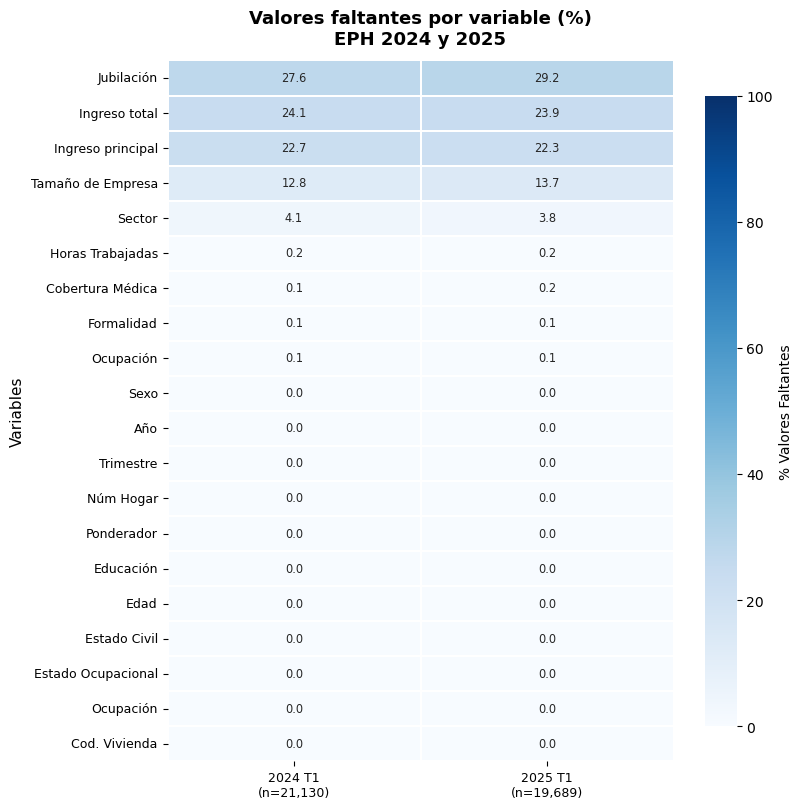

In [62]:
#Preparación para el gráfico heatmap de valores nulos

nulos_2024 = ocupados_2024.isnull().mean() * 100
nulos_2025 = ocupados_2025.isnull().mean() * 100

val_nulos = pd.DataFrame({
    f"2024 T1\n(n={len(ocupados_2024):,})": nulos_2024,
    f"2025 T1\n(n={len(ocupados_2025):,})": nulos_2025
})

renombre_var = {
    "CODUSU": "Cod. Vivienda",
    "ANO4": "Año",
    "TRIMESTRE": "Trimestre",
    "NRO_HOGAR": "Núm Hogar",
    "PONDERA": "Ponderador",
    "CH04": "Sexo",
    "CH06": "Edad",
    "CH07": "Estado Civil",
    "CH08": "Cobertura Médica",
    "NIVEL_ED": "Educación",
    "ESTADO": "Estado Ocupacional",
    "CAT_OCUP": "Ocupación",
    "EMPLEO": "Formalidad",
    "SECTOR": "Sector Laboral",
    "PP04C": "Tamaño de Empresa",
    "PP04D_COD": "Ocupación",
    "P21": "Ingreso principal",
    "P47T": "Ingreso total",
    "PP07H": "Jubilación",
    "PP3E_TOT": "Horas Trabajadas"
}

# Cambiamos las etiquetas de las filas
val_nulos = val_nulos.rename(index=renombre_var)

# Filtramos la base para conservar SOLO las variables originales y eliminamos las dummy nuevas porque es redundante (mujer, cobertura y de tamaño)
val_nulos2 = val_nulos.loc[val_nulos.index.isin(renombre_var.values())]

columna_orden = f"2024 T1\n(n={len(ocupados_2024):,})"
val_nulos2 = val_nulos2.sort_values(by=columna_orden, ascending=True)

# Invertimos el orden de las filas
val_nulos2 = val_nulos2.iloc[::-1]

fig, ax = plt.subplots(figsize=(8.2, 8.2))

sns.heatmap(
    val_nulos2,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    linewidths=0.3,
    linecolor="white",
    ax=ax,
    vmin=0, vmax=100,
    cbar_kws={"shrink": 0.9, "label": "% Valores Faltantes"},
    annot_kws={"size": 8.2}
)

ax.set_title(
    "Valores faltantes por variable (%)\nEPH 2024 y 2025",
    fontsize=13,
    fontweight="bold",
    pad=12,
    loc="center"
)
ax.set_xlabel("")
ax.set_ylabel("Variables", fontsize=11)

# Estilo Etiquetas 
ax.tick_params(axis="x", labelsize=9, rotation=0)
ax.tick_params(axis="y", labelsize=9)

# Eliminamos bordes innecesarios
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.savefig("heatmap_nulos.png", dpi=150, bbox_inches="tight")
plt.show()

Parte II: Primer Análisis Exploratorio

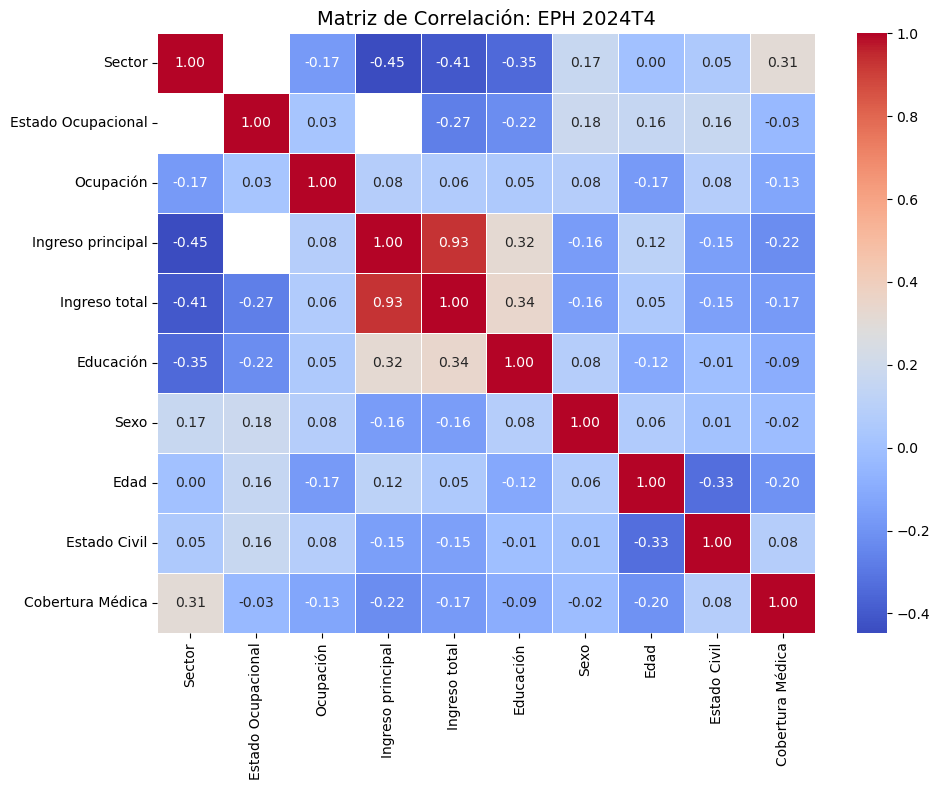

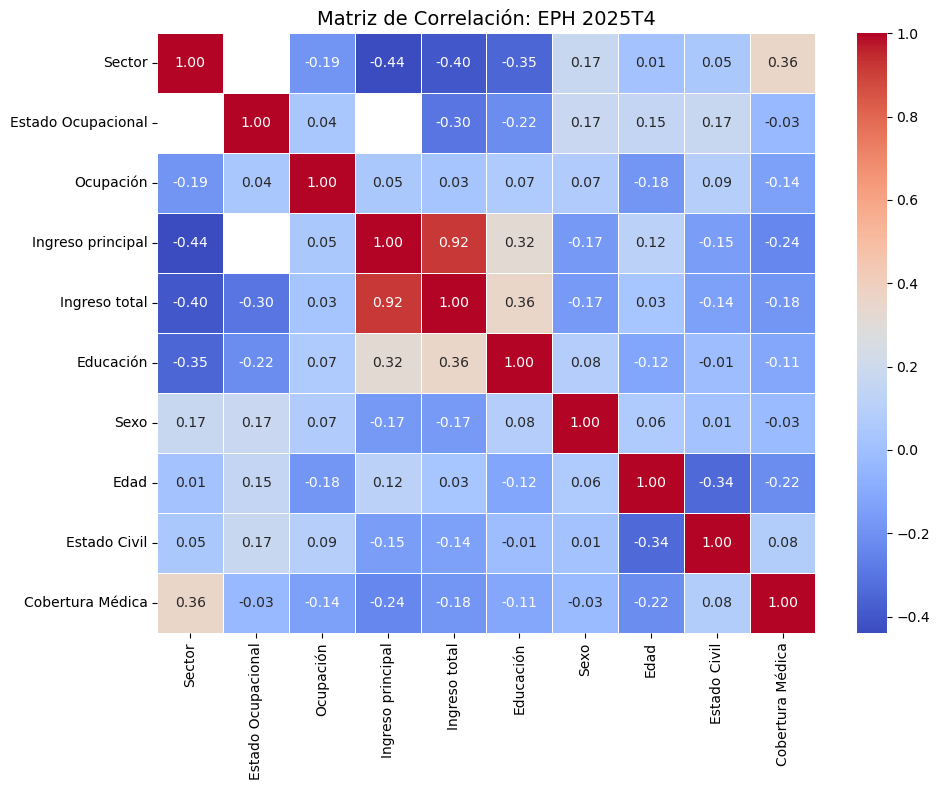

In [65]:
# Lista de variables seleccionadas pora Análisis Exploratorio
variables_seleccionadas = [
    "SECTOR", "ESTADO", "CAT_OCUP", "P21", "P47T", 
    "NIVEL_ED", "Género", "CH06", "CH07", "Cobertura"
]

def generar_heatmap_reducido(df, periodo):
    # Filtramos el dataframe solo con las variables seleccionadas
    df_subset = df[variables_seleccionadas].rename(columns=renombre_var)
    
    # Calculamos la correlación
    matriz_corr = df_subset.corr(numeric_only=True)
    
    # Graficamos
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        matriz_corr, 
        annot=True, 
        cmap='coolwarm', 
        fmt=".2f", 
        linewidths=0.5
    )
    plt.title(f"Matriz de Correlación: EPH {periodo}", fontsize=14)
    plt.tight_layout()
    plt.show()

# Ejecución
generar_heatmap_reducido(T424_v, "2024T4")
generar_heatmap_reducido(T425_v, "2025T4")

Al comparar las matrices de correlación entre el cuarto trimestre de 2024 y 2025, se observa una notable estabilidad estructural en las relaciones entre las variables socioeconómicas. La correlación entre el Ingreso Principal y el Ingreso Total se mantiene extremadamente alta y consistente, pasando de 0.93 en 2024 a 0.92 en 2025, lo que valida la coherencia interna de los datos. Asimismo, persiste una correlación positiva moderada entre el Nivel Educativo y los niveles de ingreso, que oscila entre 0.32 y 0.36, sugiriendo que el vínculo entre formación e ingresos se mantiene estable. Por otro lado, la relación negativa entre el Sector Laboral y los Ingresos (alrededor de -0.40 a -0.45) se mantiene firme en ambos periodos, al igual que la correlación inversa entre Edad y Estado Civil (~ -0.33), evidenciando que las dinámicas subyacentes capturadas por la EPH presentan una persistencia marcada entre ambos años.

In [74]:
# 1. Definimos los percentiles
percentiles_custom = [0.01, 0.25, 0.5, 0.75, 0.99]

# 2. Preparamos los DataFrames: 
# Filtramos por las variables seleccionadas y renombramos las columnas
df_2024_listo = T424_v[variables_seleccionadas].rename(columns=renombre_var)
df_2025_listo = T425_v[variables_seleccionadas].rename(columns=renombre_var)

# 3. Generamos los resúmenes estadísticos
resumen_2024 = df_2024_listo.describe(percentiles=percentiles_custom).T
resumen_2025 = df_2025_listo.describe(percentiles=percentiles_custom).T

# 4. Mostramos los resultados
print("Resumen estadístico EPH - Cuarto Trimestre 2024:")
display(resumen_2024) 

print("\nResumen estadístico EPH - Cuarto Trimestre 2025:")
display(resumen_2025)

Resumen estadístico EPH - Cuarto Trimestre 2024:


,count,mean,std,min,1%,25%,50%,75%,99%,max
Sector,20273.00,1.38,0.61,1.00,1.00,1.00,1.00,2.00,3.00,3.00
Estado Ocupacional,37839.00,1.85,0.97,1.00,1.00,1.00,1.00,3.00,3.00,3.00
Ocupación,22074.00,2.70,0.54,1.00,1.00,2.00,3.00,3.00,3.00,4.00
Ingreso principal,16329.00,615856.02,484813.16,2000.00,30560.00,280000.00,500000.00,800000.00,2500000.00,3000000.00
Ingreso total,24510.00,588927.78,469695.41,1000.00,24000.00,300000.00,450000.00,800000.00,2400000.00,3000000.00
Educación,37889.00,3.91,1.44,1.00,1.00,3.00,4.00,5.00,6.00,7.00
Sexo,37889.00,1.53,0.50,1.00,1.00,1.00,2.00,2.00,2.00,2.00
Edad,37889.00,43.59,19.00,15.00,15.00,27.00,42.00,58.00,86.00,103.00
Estado Civil,37888.00,3.17,1.65,1.00,1.00,2.00,3.00,5.00,5.00,5.00
Cobertura Médica,37851.00,2.07,1.89,1.00,1.00,1.00,1.00,4.00,12.00,123.00



Resumen estadístico EPH - Cuarto Trimestre 2025:


,count,mean,std,min,1%,25%,50%,75%,99%,max
Sector,18939.00,1.39,0.62,1.00,1.00,1.00,1.00,2.00,3.00,3.00
Estado Ocupacional,35725.00,1.86,0.97,1.00,1.00,1.00,1.00,3.00,3.00,3.00
Ocupación,20663.00,2.68,0.54,1.00,1.00,2.00,3.00,3.00,3.00,4.00
Ingreso principal,15290.00,889117.45,657502.34,3000.00,50000.00,400000.00,800000.00,1200000.00,3105500.00,4000000.00
Ingreso total,22980.00,838020.19,648765.95,700.00,30000.00,390000.00,671400.00,1095000.00,3152100.00,4000000.00
Educación,35784.00,3.89,1.44,1.00,1.00,3.00,4.00,5.00,6.00,7.00
Sexo,35784.00,1.53,0.50,1.00,1.00,1.00,2.00,2.00,2.00,2.00
Edad,35784.00,44.11,19.24,15.00,15.00,28.00,42.00,59.00,87.00,101.00
Estado Civil,35781.00,3.18,1.65,1.00,1.00,2.00,3.00,5.00,5.00,5.00
Cobertura Médica,35693.00,2.08,1.76,1.00,1.00,1.00,1.00,4.00,12.00,23.00


Al contrastar las estadísticas descriptivas del cuarto trimestre de 2024 y 2025, se observa una notable consistencia en la estructura sociodemográfica de la muestra, reflejada en variables como Educación (media de ~3.9), Edad (media de ~44 años) y Sexo, las cuales mantienen valores prácticamente invariables. En contraste, se evidencia un incremento nominal significativo en los ingresos, con el Ingreso Principal promedio escalando de 615.856 a 889.117 y el Ingreso Total de 588.927 a 838.020, un comportamiento alineado con las dinámicas inflacionarias del periodo. Esta evolución en los valores monetarios, frente a la estabilidad estructural de los indicadores poblacionales, sugiere que, tras la rigurosa depuración de outliers aplicada —que aseguró la integridad de los estimadores salariales y la comparabilidad entre ejercicios—, la muestra permite capturar adecuadamente los ajustes nominales en la capacidad adquisitiva manteniendo la representatividad estadística del universo analizado.